PROCESS

In [2]:
import pandas as pd
import re

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

1. CLEANING DATA

In [3]:
df = pd.read_csv('data_label.csv', sep=';')

df.head()

,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik


In [4]:
# cek duplikasi
df.shape

(5000, 2)

In [5]:
# drop semua yg duplikat
df = df.drop_duplicates(subset=['text'])
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [8]:
df.shape

(4583, 2)

In [9]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) #hapus mention
    text = re.sub(r'#\w+', '', text) #hapus hashtag
    text = re.sub(r'https?://\S+', '', text) #hapus URL
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text) #hapus karakter khusus
    text = re.sub(r'\s+', ' ', text).strip() #hapus spasi berlebih
    text = re.sub(r'RT[\s]+', '', text) #hapus RT
    text = re.sub(r'RE[\s]+', '', text) #hapus RE
    return text

df['text'] = df['text'].apply(clean_twitter_text)


In [10]:
df['text'] = df['text'].str.lower()

In [11]:
df

,text,label
0,kunjungan prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,anies dapat tepuk tangan meriah saat jadi rekt...,Politik
2,y8heyaiogmfg8y emng bener sih pendukung 01 ada...,Demografi
3,0hhztbqvgx7qtfwrg9zmhk7q sewaktu anies bersika...,Politik
4,anies baswedan harap asn termasuk tni dan polr...,Politik
...,...,...
4995,ngeliat debat kemaren pas prabowo kicep kekira...,Politik
4996,masyarakat yakin bahwa prabowogibran memiliki ...,Politik
4997,imo both are irrational but yg satu jauh lebih...,Ekonomi
4998,look at that pak ganjar anda sdh berkecimpung ...,Pertahanan dan Keamanan


load slang dict


In [12]:
try:
    slang_df   = pd.read_csv('slang_indo.csv', header=None, names=['slang','formal'])
    slang_dict = dict(zip(slang_df['slang'], slang_df['formal']))
    print(f'Slang loaded: {len(slang_dict)} entri')
    print(f'Contoh: {list(slang_dict.items())[:5]}')
except FileNotFoundError:
    slang_dict = {}
    print('File slang tidak ditemukan, lanjut tanpa normalisasi slang')

Slang loaded: 1250 entri
Contoh: [('aamiin', 'amin '), ('adek', 'adik '), ('adlh', 'adalah '), ('aer', 'air '), ('aiskrim', 'es krim ')]


preprocessing

In [13]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopword = stop_factory.create_stop_word_remover()

split data

In [14]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print('Kelas:', le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    df['text'].values,
    df['label_enc'].values,
    test_size    = 0.2,
    stratify     = df['label_enc'].values,
    random_state = 42
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Kelas: ['Demografi' 'Ekonomi' 'Geografi' 'Ideologi' 'Pertahanan dan Keamanan'
 'Politik' 'Sosial Budaya' 'Sumber Daya Alam']
Train: 3666 | Test: 917


TF-IDF vector

In [15]:
custom_stopwords = [
    "yang","dan","di","ke","dari","untuk","dengan","ini","itu",
    "juga","karena","ada","jadi","dalam","akan","sudah","saya",
    "kita","kami","mereka"
]

word_tfidf = TfidfVectorizer(
    analyzer     = 'word',
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.90,
    sublinear_tf = True,
    max_features = 15000,
    strip_accents = 'unicode',
    stop_words   = custom_stopwords
)
char_tfidf = TfidfVectorizer(
    analyzer     = 'char_wb',
    ngram_range  = (3, 5),
    min_df       = 2,
    max_df       = 0.90,
    sublinear_tf = True,
    max_features = 10000,
    strip_accents = 'unicode'
)

X_train_vec = hstack([
    word_tfidf.fit_transform(X_train),
    char_tfidf.fit_transform(X_train)
])
X_test_vec = hstack([
    word_tfidf.transform(X_test),
    char_tfidf.transform(X_test)
])

print(f'Shape train : {X_train_vec.shape}')
print(f'Shape test  : {X_test_vec.shape}')
print(f'Total fitur : {X_train_vec.shape[1]:,}')

Shape train : (3666, 23770)
Shape test  : (917, 23770)
Total fitur : 23,770


train svm 

In [16]:
from sklearn.svm import LinearSVC

model = LinearSVC(
    C            = 5.0,
    class_weight = 'balanced',
    max_iter     = 2000,
    random_state = 42
)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,5.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


evaluasi

                         precision    recall  f1-score   support

              Demografi       0.17      0.08      0.11        12
                Ekonomi       0.65      0.65      0.65        62
               Geografi       0.00      0.00      0.00         4
               Ideologi       0.67      0.62      0.64        68
Pertahanan dan Keamanan       0.62      0.56      0.59        66
                Politik       0.82      0.86      0.84       590
          Sosial Budaya       0.45      0.46      0.46        84
       Sumber Daya Alam       0.43      0.29      0.35        31

               accuracy                           0.74       917
              macro avg       0.48      0.44      0.45       917
           weighted avg       0.73      0.74      0.73       917

Akurasi : 0.7372


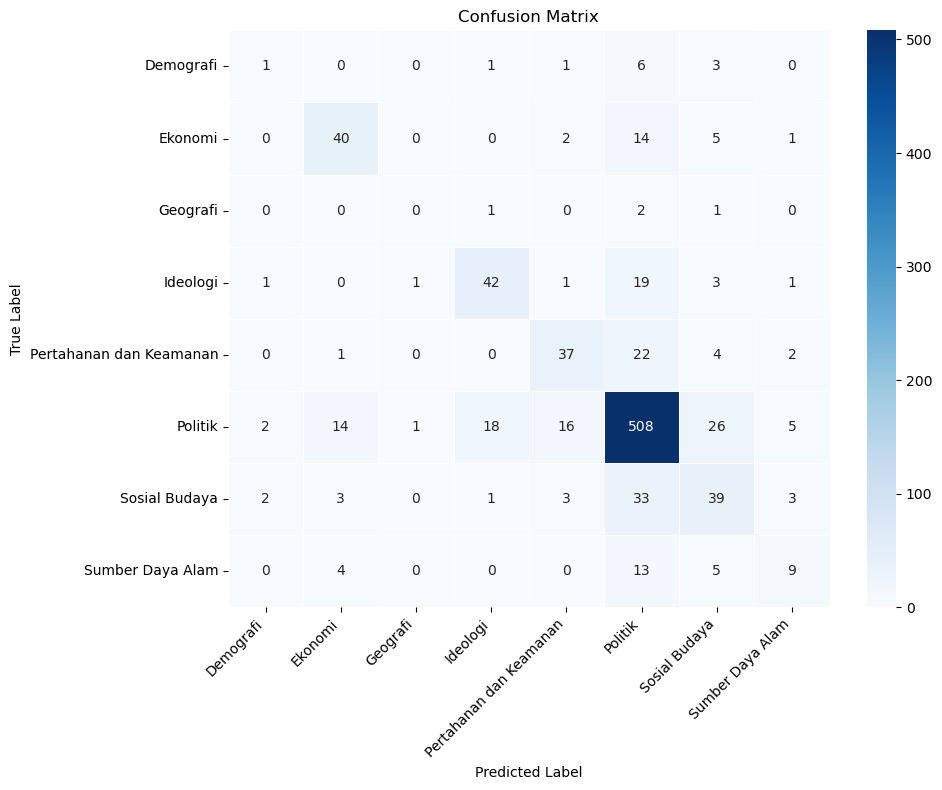

In [17]:
pred = model.predict(X_test_vec)

print(classification_report(y_test, pred, target_names=le.classes_))
print(f'Akurasi : {(pred == y_test).mean():.4f}')

# Confusion Matrix
cm  = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues', ax=ax, linewidths=0.5
)
ax.set_title('Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

tes 50k

In [18]:
# ── Step 10: Prediksi Data Unlabel ────────────────────
print('Loading data unlabel...')
df_unlabel = pd.read_csv('data_unlabel.csv', sep=';')
print(f'Shape: {df_unlabel.shape}')
print(f'Kolom: {df_unlabel.columns.tolist()}')
df_unlabel.head(3)

Loading data unlabel...
Shape: (1000, 2)
Kolom: ['IDText', 'Text']


,IDText,Text
0,TXT0001,Lu mau org2 pro-demokrasi di negara ini bisa p...
1,TXT0002,Prabowo ditanya soal hutang luar negeri dia me...
2,TXT0003,kiki_daliyo Ganjar Pranowo itulah beliau soso...


In [20]:
# ...existing code...
# Preprocessing data unlabel — pipeline sama persis
print('Cleaning...')

# pastikan kolom text ada & aman dari NaN
df_unlabel['text'] = df_unlabel['Text'].fillna('').astype(str)

# cleaning + lowercase
df_unlabel['text'] = df_unlabel['text'].apply(clean_twitter_text).str.lower()

print('Preprocessing lanjutan...')

# kalau preprocess_lanjutan belum didefinisikan, bikin fallback sederhana (tanpa slang/stopword/stemming)
if 'preprocess_lanjutan' not in globals():
    def preprocess_lanjutan(t):
        t = '' if t is None else str(t)
        return re.sub(r'\s+', ' ', t).strip()

df_unlabel['clean_text'] = df_unlabel['text'].apply(preprocess_lanjutan)

# Drop yang kosong
empty_ul = df_unlabel['clean_text'].astype(str).str.strip().eq('')
print(f'Tweet kosong: {int(empty_ul.sum())}')
df_unlabel = df_unlabel.loc[~empty_ul].reset_index(drop=True)
print(f'Data unlabel tersisa: {len(df_unlabel)}')
# ...existing code...

Cleaning...
Preprocessing lanjutan...
Tweet kosong: 0
Data unlabel tersisa: 1000


In [21]:
# Vectorize & Prediksi
X_unlabel_vec = hstack([
    word_tfidf.transform(df_unlabel['clean_text']),
    char_tfidf.transform(df_unlabel['clean_text'])
])

df_unlabel['predicted_label'] = le.inverse_transform(
    model.predict(X_unlabel_vec)
)

# Distribusi hasil prediksi
print('Distribusi prediksi:')
dist = df_unlabel['predicted_label'].value_counts()
dist_pct = df_unlabel['predicted_label'].value_counts(normalize=True) * 100
for label, cnt in dist.items():
    bar = '█' * int(dist_pct[label] / 2)
    print(f'  {label:35s}: {cnt:5d} ({dist_pct[label]:5.1f}%) {bar}')

# Simpan hasil
df_unlabel.to_csv('hasil_prediksi_unlabel.csv', index=False, sep=';')
print('\n✅ Hasil disimpan ke hasil_prediksi_unlabel.csv')
df_unlabel[['text','clean_text','predicted_label']].head(10)

Distribusi prediksi:
  Politik                            :   744 ( 74.4%) █████████████████████████████████████
  Ekonomi                            :   105 ( 10.5%) █████
  Pertahanan dan Keamanan            :    54 (  5.4%) ██
  Sosial Budaya                      :    35 (  3.5%) █
  Ideologi                           :    34 (  3.4%) █
  Sumber Daya Alam                   :    23 (  2.3%) █
  Demografi                          :     3 (  0.3%) 
  Geografi                           :     2 (  0.2%) 

✅ Hasil disimpan ke hasil_prediksi_unlabel.csv


,text,clean_text,predicted_label
0,lu mau org2 prodemokrasi di negara ini bisa pu...,lu mau org2 prodemokrasi di negara ini bisa pu...,Politik
1,prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,Politik
2,kikidaliyo ganjar pranowo itulah beliau sosok ...,kikidaliyo ganjar pranowo itulah beliau sosok ...,Ideologi
3,prabowo gibran yang bisa melakukan itu semua d...,prabowo gibran yang bisa melakukan itu semua d...,Politik
4,lah justru yg gak nyambung junjungan elu aomkm...,lah justru yg gak nyambung junjungan elu aomkm...,Ekonomi
5,nelayan tak bisa terus terjebak dalam kredit m...,nelayan tak bisa terus terjebak dalam kredit m...,Politik
6,prabowo anti kebebasan pers,prabowo anti kebebasan pers,Politik
7,kontrak terbuka ganjar pranowo adalah cermin d...,kontrak terbuka ganjar pranowo adalah cermin d...,Politik
8,ganjar mahfud hebat pak ganjar selalu menjungj...,ganjar mahfud hebat pak ganjar selalu menjungj...,Politik
9,ganjarmahfud adalah harapan baru untuk pertumb...,ganjarmahfud adalah harapan baru untuk pertumb...,Ekonomi
